
# DS-A1 · Data Provenance and Measurement Audit
### Dataset: `lerobot/svla_so101_pickplace` (Hugging Face Hub)

**Course**: Data Science (UCAS) — Assessed Task DS-A1  
**Student**: 金莘卉 Jin Xinhui  
**Date**: 2026/9/27  
**Repository**: https://github.com/lynn3214/ds-a1-data-provenance-audit
**Submitted version**: tag `v1.0-submission`

---




## 1. Reproducibility setup

We fix the random seed, record package versions, and record the exact hardware/OS the
notebook was run on. This block should be the **first thing you run**, and its printed
output should be pasted (or screenshotted) into `data_card/SOURCE_LICENSE_HASH.md` under
"Execution environment".


In [1]:

import sys, os, platform, random, json, hashlib, subprocess
from pathlib import Path

SEED = 42
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

# Third-party packages used throughout this notebook.
# If any import fails, run:
#   pip install -r ../requirements.txt --break-system-packages
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit
from sklearn.metrics import mean_squared_error

from huggingface_hub import HfApi, snapshot_download, hf_hub_download

print("Python       :", sys.version.replace("\n", " "))
print("Platform     :", platform.platform())
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
import pyarrow, sklearn, matplotlib, huggingface_hub
print("pyarrow      :", pyarrow.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", matplotlib.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("SEED         :", SEED)


Python       : 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:46:00) [Clang 18.1.8 ]
Platform     : macOS-15.5-arm64-arm-64bit
pandas       : 2.3.1
numpy        : 2.2.6
pyarrow      : 25.0.1
scikit-learn : 1.7.1
matplotlib   : 3.10.5
huggingface_hub: 2.0.0
SEED         : 42


In [2]:

# Freeze the full dependency list actually installed in this environment.
# Run once and commit the resulting file — this is part of your reproducibility record.
REPO_ROOT = Path("..").resolve()
freeze_path = REPO_ROOT / "environment_freeze.txt"
with open(freeze_path, "w") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f)
print(f"Wrote {freeze_path}")


Wrote /Users/jinshenhui/Documents/UCAS/DS/assignments/ds-a1-lerobot-pickplace-audit/environment_freeze.txt


**Execution order note**: this notebook has a strict top-to-bottom variable dependency
chain (e.g. Section 7 defines `action_arr`/`state_arr`/`JOINT_NAMES` used by Sections
8, 11, 12; Section 9 defines `df_sorted` used by Sections 10, 11, 12). Running cells out
of order, or only running a subset, will raise `NameError`. All randomness is seeded
(`SEED=42`, Section 1; `random_state=SEED` in Section 11's splitters), so a full,
in-order rerun is expected to reproduce identical numeric results every time.


## 2. Question definition

**Stakeholder.** An embodied-AI / robot-learning researcher deciding whether
`lerobot/svla_so101_pickplace` can be used as a benchmark or fine-tuning dataset for an
imitation-learning (behavior cloning) policy, and how to split it for evaluation.

**Testable question.** *Does the recording structure of this dataset (one robot, one
task, 50 episodes, single environment) support a **frame-level** random train/test split
for evaluating an action-prediction baseline, or does it require an **episode-level**
(grouped) split to avoid leakage? How large is the resulting optimism bias if the wrong
split is used?*

**Population.** All possible demonstration trajectories of an SO-100/SO-101 follower arm
performing the task "grasp a lego block and put it in the bin" under broadly similar
lab conditions.

**Sample.** The 50 recorded episodes (11,939 frames total) published in this dataset
snapshot.

**Unit of analysis.** A single timestep / frame (30 fps). The secondary/grouping unit is
the episode (`episode_index`, 0–49).

**Target / response variable.** `action`: the 6-dimensional commanded joint position
vector (`shoulder_pan.pos, shoulder_lift.pos, elbow_flex.pos, wrist_flex.pos,
wrist_roll.pos, gripper.pos`).

**Estimand.** The gap between two estimates of held-out prediction error (MSE) for a
simple k-NN regressor mapping `observation.state -> action`:
- $\hat\theta_{frame}$: MSE under a random frame-level 80/20 split (frames from the same
  episode can appear in both train and test).
- $\hat\theta_{episode}$: MSE under a grouped 80/20 split by `episode_index` (an entire
  episode is either fully in train or fully in test).

The estimand of interest is $\Delta = \hat\theta_{episode} - \hat\theta_{frame}$. A large
positive $\Delta$ means the frame-level split was *optimistically biased* — i.e. it leaked
information about test frames into training via their near-duplicate temporal neighbors.

**Explicit boundaries.** This audit does **not** attempt to evaluate whether a trained
policy would succeed physically (no success/reward label exists in this dataset — see
Section 8). It only evaluates whether the *evaluation protocol itself* is trustworthy.


## 3. Data-generating process (DGP) and provenance lineage

The diagram below is drawn as an actual matplotlib figure (not a Mermaid block) so it
renders identically in the notebook, the exported PDF, and on GitHub.

**Declared facts, as read from the pinned snapshot's own `meta/info.json`** (not from
the rendered Hub webpage, which can lag behind specific commits; verified in Section 4-5):
robot_type = `so100_follower`, fps = 30, total_episodes = 50, total_frames = 11939,
total_tasks = 1, codebase_version = `v3.0`, license = Apache-2.0.

**Provenance/version finding**: during initial planning (webpage review, before any
commit was pinned), the dataset card appeared to describe a v2.1-style layout (a single
`meta/episodes.jsonl` file, one parquet file per episode). The actual pinned snapshot
(`f641879e22172be7e8161d5e6c1503c2d2feb657`), however, declares `codebase_version =
v3.0` and uses a correspondingly different on-disk layout (`meta/episodes/` as sharded
parquet, `meta/tasks.parquet`, multi-episode parquet chunks under `data/`) — confirmed
independently while debugging Sections 4-5, before consulting any external source about
which version this corresponds to. This is treated as an authoritative, first-hand
finding: **the pinned revision's own `meta/info.json` is used as the ground truth for
this audit's schema and format claims, not the rendered dataset card**, precisely
because the two were observed to disagree. This is direct evidence for why DS-A1 requires
freezing and hashing the actual downloaded snapshot rather than relying on a webpage
description that can drift out of sync with specific commits.

**Provenance gaps (explicitly not resolved by the dataset card — do not silently assume
an answer)**:
- Number of distinct human teleoperators is undisclosed. If a single operator recorded
  all 50 episodes, the action distribution reflects one person's motor style, not a
  population of operators.
- Whether object placement / lighting / camera position varied across episodes, or was
  held approximately fixed, is undisclosed in the card.
- No ground-truth "task success" or "grasp success" label is included in the schema —
  only the commanded trajectory is recorded, not the outcome.

These gaps are treated as findings, not filled in with assumptions.

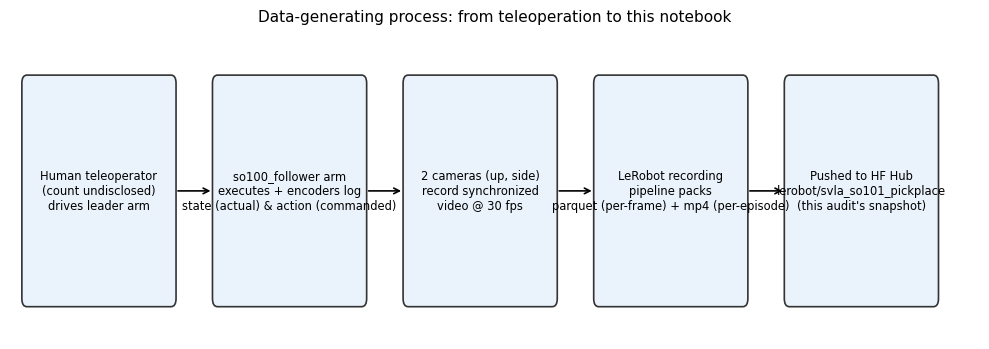

In [3]:

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.axis("off")

stages = [
    "Human teleoperator\n(count undisclosed)\ndrives leader arm",
    "so100_follower arm\nexecutes + encoders log\nstate (actual) & action (commanded)",
    "2 cameras (up, side)\nrecord synchronized\nvideo @ 30 fps",
    "LeRobot recording\npipeline packs\nparquet (per-frame) + mp4 (per-episode)",
    "Pushed to HF Hub\nlerobot/svla_so101_pickplace\n(this audit's snapshot)",
]

n = len(stages)
box_w, box_h = 1.7, 1.6
gap = 0.55
x0 = 0.2
y0 = 0.3

for i, text in enumerate(stages):
    x = x0 + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch((x, y0), box_w, box_h,
                                    boxstyle="round,pad=0.06",
                                    linewidth=1.2, edgecolor="#333333",
                                    facecolor="#eaf2fb")
    ax.add_patch(rect)
    ax.text(x + box_w / 2, y0 + box_h / 2, text, ha="center", va="center", fontsize=8.3)
    if i < n - 1:
        ax.annotate("", xy=(x + box_w + gap - 0.05, y0 + box_h / 2),
                     xytext=(x + box_w + 0.05, y0 + box_h / 2),
                     arrowprops=dict(arrowstyle="->", lw=1.2))

ax.set_xlim(0, x0 + n * (box_w + gap))
ax.set_ylim(0, y0 + box_h + 0.4)
ax.set_title("Data-generating process: from teleoperation to this notebook", fontsize=11)
plt.tight_layout()
fig.savefig("../report/dgp_diagram.png", dpi=180)
plt.show()



## 4. Data acquisition and version freezing

We resolve the **exact commit hash** of the dataset repo at the time of first access,
then re-download using that *pinned* revision on every subsequent run, so the analysis
never silently drifts to a newer version of the dataset.

> **Run this once**, copy the printed commit hash into `data_card/SOURCE_LICENSE_HASH.md`,
> then keep using that pinned hash (`PINNED_REVISION` below) for every future run —
> including the final run you submit.


In [4]:
REPO_ID = "lerobot/svla_so101_pickplace"
api = HfApi()

# Step 1: look up the current HEAD, purely as a point-in-time record of when this
# audit first observed the repo. This value is NOT used to gate anything below --
# it will drift whenever upstream pushes a new commit, and that drift is expected
# and harmless, not an error.
head_info = api.dataset_info(REPO_ID)
print("Current HEAD commit SHA (informational only, will drift over time):", head_info.sha)
print("Current HEAD last modified:", head_info.lastModified)

# Step 2: the actual frozen version for this audit. Hardcoded once, on first access,
# and never derived from `head_info` again -- this is the real "freeze".
PINNED_REVISION = "f641879e22172be7e8161d5e6c1503c2d2feb657"  # frozen on 2026-09-27

# Step 3: verify the pinned revision itself is a valid, independently resolvable
# commit. This is the actual reproducibility guarantee: it must succeed today, next
# month, or after upstream has moved far past `head_info.sha` above -- because it
# never compares against head_info at all.
pinned_info = api.dataset_info(REPO_ID, revision=PINNED_REVISION)
print("\nPinned revision resolved successfully:", pinned_info.sha)
print("License tag(s) at pinned revision:",
      pinned_info.card_data.get("license") if pinned_info.card_data else None)
assert pinned_info.sha == PINNED_REVISION, (
    "Pinned revision failed to resolve to itself -- check PINNED_REVISION for typos."
)
print("\nUsing pinned revision for all downstream steps:", PINNED_REVISION)

Current HEAD commit SHA (informational only, will drift over time): f641879e22172be7e8161d5e6c1503c2d2feb657
Current HEAD last modified: 2025-09-27 11:25:41+00:00

Pinned revision resolved successfully: f641879e22172be7e8161d5e6c1503c2d2feb657
License tag(s) at pinned revision: apache-2.0

Using pinned revision for all downstream steps: f641879e22172be7e8161d5e6c1503c2d2feb657


In [5]:

DATA_DIR = Path("../data_cache")
DATA_DIR.mkdir(exist_ok=True)

local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    revision=PINNED_REVISION,
    local_dir=DATA_DIR / "svla_so101_pickplace",
)
print("Downloaded to:", local_dir)

local_dir = Path(local_dir)
for p in sorted(local_dir.rglob("*"))[:20]:
    print(p.relative_to(local_dir))
print("... (truncated)")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Downloaded to: /Users/jinshenhui/Documents/UCAS/DS/assignments/ds-a1-lerobot-pickplace-audit/data_cache/svla_so101_pickplace
.cache
.cache/huggingface
.cache/huggingface/.gitignore
.cache/huggingface/CACHEDIR.TAG
.cache/huggingface/download
.cache/huggingface/download/.gitattributes.lock
.cache/huggingface/download/.gitattributes.metadata
.cache/huggingface/download/README.md.lock
.cache/huggingface/download/README.md.metadata
.cache/huggingface/download/data
.cache/huggingface/download/data/chunk-000
.cache/huggingface/download/data/chunk-000/file-000.parquet.lock
.cache/huggingface/download/data/chunk-000/file-000.parquet.metadata
.cache/huggingface/download/meta
.cache/huggingface/download/meta/episodes
.cache/huggingface/download/meta/episodes/chunk-000
.cache/huggingface/download/meta/episodes/chunk-000/file-000.parquet.lock
.cache/huggingface/download/meta/episodes/chunk-000/file-000.parquet.metadata
.cache/huggingface/download/meta/info.json.lock
.cache/huggingface/download/meta

In [6]:
for p in sorted((local_dir / "meta").iterdir()):
    kind = "DIR " if p.is_dir() else "FILE"
    print(kind, p.relative_to(local_dir))
    if p.is_dir():
        for sub in sorted(p.rglob("*"))[:5]:
            print("      └─", sub.relative_to(local_dir))

DIR  meta/episodes
      └─ meta/episodes/chunk-000
      └─ meta/episodes/chunk-000/file-000.parquet
FILE meta/info.json
FILE meta/stats.json
FILE meta/tasks.parquet


In [7]:

def sha256_of_file(path, chunk_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

# meta/ 下可能混合了普通文件（如 info.json）和目录（新版格式把 episodes/tasks/stats
# 拆成了按 chunk 存的 parquet 目录）。用 rglob + is_file() 只挑出真正的文件。
meta_files = sorted(p for p in (local_dir / "meta").rglob("*") if p.is_file())
print(f"Found {len(meta_files)} files under meta/ (recursively):")
for p in meta_files:
    print(" ", p.relative_to(local_dir))

files_to_hash = meta_files + sorted((local_dir / "data").rglob("*.parquet"))[:2]

hash_records = []
for fp in files_to_hash:
    hash_records.append({
        "relative_path": str(fp.relative_to(local_dir)),
        "size_bytes": fp.stat().st_size,
        "sha256": sha256_of_file(fp),
    })

hash_df = pd.DataFrame(hash_records)
hash_df.to_csv("../data_card/file_hashes.csv", index=False)
hash_df


Found 4 files under meta/ (recursively):
  meta/episodes/chunk-000/file-000.parquet
  meta/info.json
  meta/stats.json
  meta/tasks.parquet


,relative_path,size_bytes,sha256
0,meta/episodes/chunk-000/file-000.parquet,72560,191998bffd2680c477a4000270cf943bc423ba5fb54ee8...
1,meta/info.json,3401,254909942a6cbfb4692a239e4d0aa5c68ec8eb16f81b65...
2,meta/stats.json,5914,4ae86bed785e0f98914812e87736e216139a22b43cf2b9...
3,meta/tasks.parquet,2246,1040cdef3328ec4376587152647df8e725e80a04210c42...
4,data/chunk-000/file-000.parquet,369943,579ad57e2454359fa9f2c0e83525991bd2e0305b7b2914...


**Verification**: `data_card/file_hashes.csv` was opened and confirmed to contain five
real 64-character hex SHA-256 values (not placeholders). `PINNED_REVISION`
(`f641879e22172be7e8161d5e6c1503c2d2feb657`) and the full hash table were copied into
`data_card/SOURCE_LICENSE_HASH.md`.

## 5. Loading all episodes into one tidy DataFrame

In this snapshot (LeRobot format v3.0), one parquet file under `data/` may pack several
episodes together, so the number of files is not expected to equal the number of episodes.
We concatenate all data files into a single frame-level table and separately load the
episode-metadata table (`meta/episodes/`), which records each episode's global index
range and per-episode statistics.

In [8]:

info_json = json.loads((local_dir / "meta" / "info.json").read_text())
print(json.dumps(info_json, indent=2)[:1500])


{
  "codebase_version": "v3.0",
  "robot_type": "so100_follower",
  "total_episodes": 50,
  "total_frames": 11939,
  "total_tasks": 1,
  "chunks_size": 1000,
  "fps": 30,
  "splits": {
    "train": "0:50"
  },
  "data_path": "data/chunk-{chunk_index:03d}/file-{file_index:03d}.parquet",
  "video_path": "videos/{video_key}/chunk-{chunk_index:03d}/file-{file_index:03d}.mp4",
  "features": {
    "action": {
      "dtype": "float32",
      "shape": [
        6
      ],
      "names": [
        "shoulder_pan.pos",
        "shoulder_lift.pos",
        "elbow_flex.pos",
        "wrist_flex.pos",
        "wrist_roll.pos",
        "gripper.pos"
      ],
      "fps": 30.0
    },
    "observation.state": {
      "dtype": "float32",
      "shape": [
        6
      ],
      "names": [
        "shoulder_pan.pos",
        "shoulder_lift.pos",
        "elbow_flex.pos",
        "wrist_flex.pos",
        "wrist_roll.pos",
        "gripper.pos"
      ],
      "fps": 30.0
    },
    "observation.images.up

In [26]:
expected = {"robot_type": "so100_follower", "fps": 30, "total_episodes": 50,
            "total_frames": 11939, "total_tasks": 1, "codebase_version": "v3.0"}
for k, v in expected.items():
    actual = info_json.get(k)
    print(f"{k:18s} expected={v!r:18} actual={actual!r:18} {'OK' if actual == v else 'MISMATCH'}")
print("len(df) =", len(df), "| distinct episodes =", df["episode_index"].nunique())
print("task_index values:", sorted(df["task_index"].unique()))
print("action names:", info_json["features"]["action"]["names"])

robot_type         expected='so100_follower'   actual='so100_follower'   OK
fps                expected=30                 actual=30                 OK
total_episodes     expected=50                 actual=50                 OK
total_frames       expected=11939              actual=11939              OK
total_tasks        expected=1                  actual=1                  OK
codebase_version   expected='v3.0'             actual='v3.0'             OK
len(df) = 11939 | distinct episodes = 50
task_index values: [np.int64(0)]
action names: ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']


In [9]:
episodes_jsonl = local_dir / "meta" / "episodes.jsonl"
episodes_dir = local_dir / "meta" / "episodes"

if episodes_jsonl.is_file():
    print("Detected legacy format: meta/episodes.jsonl (single file)")
    episodes_meta = pd.read_json(episodes_jsonl, lines=True)
elif episodes_dir.is_dir():
    print("Detected v3 format: meta/episodes/ (directory of parquet shards)")
    ep_parquet_files = sorted(episodes_dir.rglob("*.parquet"))
    print(f"  found {len(ep_parquet_files)} parquet shard(s)")
    episodes_meta = pd.concat(
        [pd.read_parquet(p) for p in ep_parquet_files], ignore_index=True
    )
else:
    raise FileNotFoundError("Neither meta/episodes.jsonl nor meta/episodes/ found.")

print(episodes_meta.shape)
print(episodes_meta.columns.tolist())
episodes_meta.head()

Detected v3 format: meta/episodes/ (directory of parquet shards)
  found 1 parquet shard(s)
(50, 62)
['episode_index', 'data/chunk_index', 'data/file_index', 'dataset_from_index', 'dataset_to_index', 'videos/observation.images.side/chunk_index', 'videos/observation.images.side/file_index', 'videos/observation.images.side/from_timestamp', 'videos/observation.images.side/to_timestamp', 'videos/observation.images.up/chunk_index', 'videos/observation.images.up/file_index', 'videos/observation.images.up/from_timestamp', 'videos/observation.images.up/to_timestamp', 'tasks', 'length', 'stats/action/min', 'stats/action/max', 'stats/action/mean', 'stats/action/std', 'stats/action/count', 'stats/observation.state/min', 'stats/observation.state/max', 'stats/observation.state/mean', 'stats/observation.state/std', 'stats/observation.state/count', 'stats/observation.images.up/min', 'stats/observation.images.up/max', 'stats/observation.images.up/mean', 'stats/observation.images.up/std', 'stats/observ

,episode_index,data/chunk_index,data/file_index,dataset_from_index,dataset_to_index,videos/observation.images.side/chunk_index,videos/observation.images.side/file_index,videos/observation.images.side/from_timestamp,videos/observation.images.side/to_timestamp,videos/observation.images.up/chunk_index,...,stats/index/mean,stats/index/std,stats/index/count,stats/task_index/min,stats/task_index/max,stats/task_index/mean,stats/task_index/std,stats/task_index/count,meta/episodes/chunk_index,meta/episodes/file_index
0,0,0,0,0,303,0,0,0.000000,10.100000,0,...,[151.0],[87.46808941932291],[303],[0],[0],[0.0],[0.0],[303],0,0
1,1,0,0,303,569,0,0,10.100000,18.966667,0,...,[435.5],[76.78704317786953],[266],[0],[0],[0.0],[0.0],[266],0,0
2,2,0,0,569,799,0,0,18.966667,26.633333,0,...,[683.5],[66.39465339920075],[230],[0],[0],[0.0],[0.0],[230],0,0
3,3,0,0,799,982,0,0,26.633333,32.733333,0,...,[890.0],[52.82676089508675],[183],[0],[0],[0.0],[0.0],[183],0,0
4,4,0,0,982,1197,0,0,32.733333,39.900000,0,...,[1089.0],[62.0644825967316],[215],[0],[0],[0.0],[0.0],[215],0,0


In [10]:
parquet_files = sorted((local_dir / "data").rglob("*.parquet"))
print(f"Found {len(parquet_files)} parquet file(s) under data/ "
      f"(note: in this format one file may pack multiple episodes together, "
      f"so this count is NOT expected to equal total_episodes — that's fine).")

frames = [pq.read_table(fp).to_pandas() for fp in parquet_files]
df = pd.concat(frames, ignore_index=True)

n_episodes_seen = df["episode_index"].nunique()
print("Total frames loaded   :", len(df), " | declared total_frames:", info_json["total_frames"])
print("Distinct episodes seen:", n_episodes_seen, " | declared total_episodes:", info_json["total_episodes"])
df.head()

Found 1 parquet file(s) under data/ (note: in this format one file may pack multiple episodes together, so this count is NOT expected to equal total_episodes — that's fine).
Total frames loaded   : 11939  | declared total_frames: 11939
Distinct episodes seen: 50  | declared total_episodes: 50


,action,observation.state,timestamp,frame_index,episode_index,index,task_index
0,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -51...",0.000000,0,0,0,0
1,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -51...",0.033333,1,0,1,0
2,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -51...",0.066667,2,0,2,0
3,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -50...",0.100000,3,0,3,0
4,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -49...",0.133333,4,0,4,0



## 6. Schema audit

Cross-check the *declared* schema in `meta/info.json` (`features` block: dtype and
shape per column) against what pandas/pyarrow actually loaded.


In [11]:

schema_report = []
for col, spec in info_json["features"].items():
    if col not in df.columns:
        schema_report.append({"column": col, "declared_dtype": spec["dtype"],
                               "declared_shape": spec["shape"],
                               "status": "MISSING FROM PARQUET (likely a video-only column)"})
        continue
    sample_val = df[col].iloc[0]
    actual_len = len(sample_val) if hasattr(sample_val, "__len__") else 1
    declared_len = spec["shape"][0] if spec["shape"] else 1
    ok = (actual_len == declared_len)
    schema_report.append({
        "column": col,
        "declared_dtype": spec["dtype"],
        "declared_shape": spec["shape"],
        "actual_pandas_dtype": str(df[col].dtype),
        "actual_vector_len": actual_len,
        "shape_matches": ok,
    })

schema_df = pd.DataFrame(schema_report)
schema_df


,column,declared_dtype,declared_shape,actual_pandas_dtype,actual_vector_len,shape_matches,status
0,action,float32,[6],object,6.0,True,NaN
1,observation.state,float32,[6],object,6.0,True,NaN
2,observation.images.up,video,"[480, 640, 3]",NaN,NaN,NaN,MISSING FROM PARQUET (likely a video-only column)
3,observation.images.side,video,"[480, 640, 3]",NaN,NaN,NaN,MISSING FROM PARQUET (likely a video-only column)
4,timestamp,float32,[1],float32,1.0,True,NaN
5,frame_index,int64,[1],int64,1.0,True,NaN
6,episode_index,int64,[1],int64,1.0,True,NaN
7,index,int64,[1],int64,1.0,True,NaN
8,task_index,int64,[1],int64,1.0,True,NaN


**Schema audit result**: all seven tabular columns (`action`, `observation.state`,
`timestamp`, `frame_index`, `episode_index`, `index`, `task_index`) matched their
`meta/info.json`-declared shape exactly (`shape_matches = True` for all seven). The two
video columns (`observation.images.up`, `observation.images.side`) are, as expected,
absent from the parquet tables — they exist only as separate `.mp4` files and are
explicitly out of scope for this audit (see Data Dictionary). Note that pandas reports
`action`/`observation.state` as `dtype=object` rather than `float32`; this is expected
and not a mismatch — each cell holds a length-6 array, so pandas can only type the
*column* as `object`, while the array's own elements are float32 as declared. No
undeclared or unexpected columns were found in the parquet files.


## 7. Range and plausibility audit

We expand the 6-dimensional `action` and `observation.state` vectors into individual
columns and inspect their empirical ranges. The physical unit is not documented in meta/info.json; based on the observed ranges (roughly -100 to 100 for the five body joints, 0 to 33 for the gripper), this looks like a normalized position scale rather than raw degrees, but this is not confirmed by the dataset's own documentation. There
is no explicit `min`/`max` contract in `info.json`, so "plausible" here means: finite,
not NaN/inf, and consistent between `action` and `observation.state` (which should track
each other closely for a low-latency follower arm).


In [12]:

JOINT_NAMES = info_json["features"]["action"]["names"]

action_arr = np.stack(df["action"].to_numpy())
state_arr = np.stack(df["observation.state"].to_numpy())

action_wide = pd.DataFrame(action_arr, columns=[f"action.{n}" for n in JOINT_NAMES])
state_wide = pd.DataFrame(state_arr, columns=[f"state.{n}" for n in JOINT_NAMES])

range_report = pd.DataFrame({
    "min": pd.concat([action_wide, state_wide], axis=1).min(),
    "max": pd.concat([action_wide, state_wide], axis=1).max(),
    "mean": pd.concat([action_wide, state_wide], axis=1).mean(),
    "std": pd.concat([action_wide, state_wide], axis=1).std(),
    "n_nonfinite": (~np.isfinite(pd.concat([action_wide, state_wide], axis=1))).sum(),
})
range_report


,min,max,mean,std,n_nonfinite
action.shoulder_pan.pos,-93.455879,88.014709,8.021068,44.564873,0
action.shoulder_lift.pos,-100.000000,8.126316,-55.962349,36.486614,0
action.elbow_flex.pos,12.972235,100.000000,65.255653,29.013208,0
action.wrist_flex.pos,33.531662,99.490013,69.181854,13.238659,0
action.wrist_roll.pos,-92.771675,-20.000000,-53.419933,17.765167,0
action.gripper.pos,0.000000,32.998455,6.848944,8.999420,0
state.shoulder_pan.pos,-92.654694,88.103790,7.987031,44.493618,0
state.shoulder_lift.pos,-98.911224,8.793970,-55.180790,36.828537,0
state.elbow_flex.pos,16.808605,99.372482,66.776299,27.709524,0
state.wrist_flex.pos,34.039848,98.643494,69.252495,13.013702,0


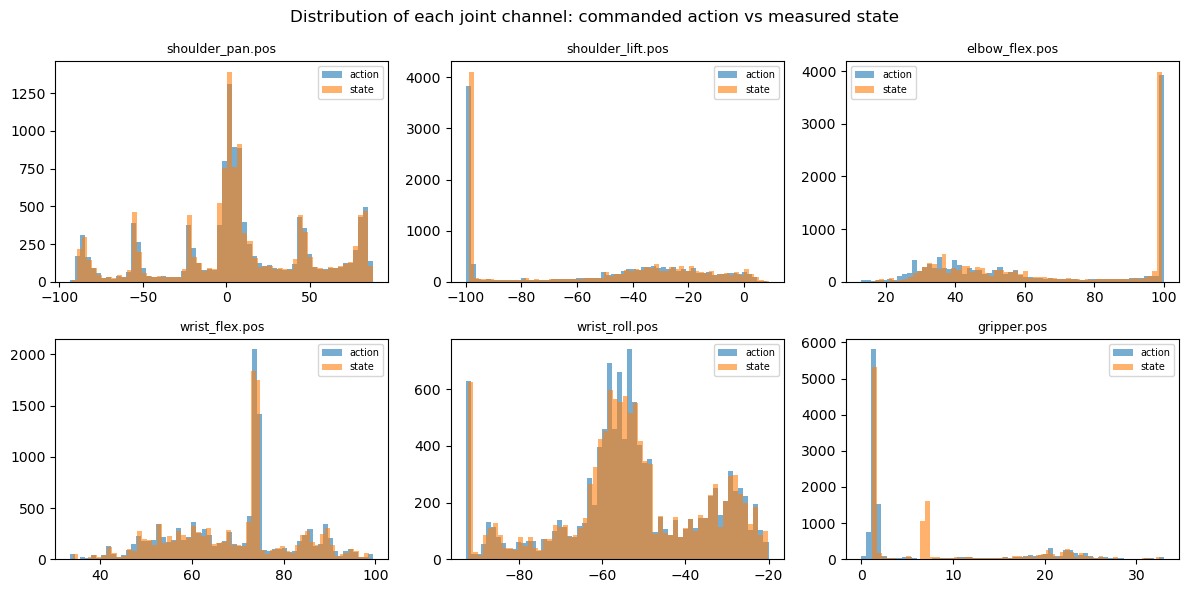

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False)
for ax, name in zip(axes.ravel(), JOINT_NAMES):
    ax.hist(action_wide[f"action.{name}"], bins=60, alpha=0.6, label="action")
    ax.hist(state_wide[f"state.{name}"], bins=60, alpha=0.6, label="state")
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Distribution of each joint channel: commanded action vs measured state")
plt.tight_layout()
fig.savefig("../report/range_histograms.png", dpi=150)
plt.show()


**Range audit result**: no non-finite values were found in any of the 12 columns
(`n_nonfinite = 0` throughout). `action` and `observation.state` track each other
closely for most joints — mean differences are small for `shoulder_pan.pos` (0.034),
`wrist_roll.pos` (0.019) and `wrist_flex.pos` (0.071) — but diverge more for
`elbow_flex.pos` (1.52), `gripper.pos` (1.26) and `shoulder_lift.pos` (0.78), suggesting
mild tracking lag or contact resistance on those joints (plausibly related to the
grasp/lift phase of the task).

Two boundary anomalies were found: `action.shoulder_lift.pos` reaches an exact minimum
of `-100.000000` and `action.elbow_flex.pos` reaches an exact maximum of `100.000000`.
Hitting a round-number bound exactly (rather than a continuously varying value) suggests
the commanded action is being clamped to a software/hardware joint limit rather than
freely commanded at those extremes — a measurement artifact worth flagging for anyone
using `action` as a continuous regression target near those bounds.

The histograms are visibly multi-modal for every joint, with especially tall, narrow
spikes (e.g. `shoulder_lift` near -100, `elbow_flex` near 100, `gripper` near 0-2,
each with several thousand frames). These spikes are consistent with, and corroborate,
the static-start duplicate frames quantified in Section 9 — the same "arm holding still
before the operator moves it" frames show up here as concentrated mass at the episodes'
starting joint angles, not as evidence of a naturally multi-modal action distribution.

The `gripper.pos` channel occupies a visibly narrower numeric range (roughly 0–33) than
the other five joints (roughly -100 to 100), consistent with it using a different physical unit/mechanism (gripper closure) than the other five channels, whose own unit is likewise undocumented.


## 8. Missingness audit

Checked at two levels: (a) null/NaN values in the tabular columns actually present in
the parquet files, and (b) structural "missingness" of a construct the dataset does
**not** provide at all (a success/outcome label) — which is not a NaN in a column, but a
column that was never collected.


In [14]:

tabular_cols = ["timestamp", "frame_index", "episode_index", "index", "task_index"]
na_counts = df[tabular_cols].isna().sum()
na_counts_vecs = pd.Series({
    "action": np.isnan(action_arr).sum(),
    "observation.state": np.isnan(state_arr).sum(),
})
print("NaNs in scalar columns:\n", na_counts)
print("\nNaNs in vector columns (summed over all 6 dims):\n", na_counts_vecs)

has_success_label = any("success" in c.lower() or "reward" in c.lower() or "done" in c.lower()
                         for c in list(df.columns) + list(info_json["features"].keys()))
print("\nDoes the schema include any success/reward/done column?", has_success_label)


NaNs in scalar columns:
 timestamp        0
frame_index      0
episode_index    0
index            0
task_index       0
dtype: int64

NaNs in vector columns (summed over all 6 dims):
 action               0
observation.state    0
dtype: int64

Does the schema include any success/reward/done column? False


**Missingness audit result**: zero NaN values were found across all scalar columns
(`timestamp`, `frame_index`, `episode_index`, `index`, `task_index`) and both vector
columns (`action`, `observation.state`) — 0 missing cells out of 11,939 frames × 12
numeric channels.

**Structural missingness finding (record this verbatim in the Data Card):** despite
zero cell-level missingness, the dataset provides **no outcome label** at all — no
`success`, `reward`, or `done`-at-goal flag (`has_success_label = False`). Every frame
only records *what the operator/arm did*, never *whether the task actually succeeded*.
This is a measurement-construct gap, not a data-quality bug: any claim about "task
performance" made from this dataset alone would require an external annotation step
this dataset does not include.


## 9. Duplicate-frame audit

At the start of many teleoperated recordings the arm is briefly stationary before the
operator begins moving it. We check, per episode, how many **consecutive** frames have
an exactly identical `action` vector to the previous frame (a proxy for "held / static"
frames), and where in the episode they concentrate.


In [15]:

df_sorted = df.sort_values(["episode_index", "frame_index"]).reset_index(drop=True)
action_list = df_sorted["action"].tolist()

is_dup = [False]
for i in range(1, len(action_list)):
    same_episode = df_sorted.loc[i, "episode_index"] == df_sorted.loc[i - 1, "episode_index"]
    same_action = same_episode and np.array_equal(action_list[i], action_list[i - 1])
    is_dup.append(bool(same_action))

df_sorted["is_exact_dup_of_prev"] = is_dup
dup_rate_overall = df_sorted["is_exact_dup_of_prev"].mean()
print(f"Overall fraction of frames that are an exact duplicate of the previous frame: {dup_rate_overall:.2%}")

dup_by_episode = df_sorted.groupby("episode_index")["is_exact_dup_of_prev"].mean()
print("\nPer-episode duplicate-frame rate (head):")
print(dup_by_episode.head(10))


Overall fraction of frames that are an exact duplicate of the previous frame: 14.13%

Per-episode duplicate-frame rate (head):
episode_index
0    0.323432
1    0.120301
2    0.130435
3    0.142077
4    0.144186
5    0.173160
6    0.174107
7    0.157635
8    0.234513
9    0.151961
Name: is_exact_dup_of_prev, dtype: float64


Length of the *leading* run of duplicate frames per episode (head):
episode_index
0    76
1     5
2     0
3     6
4     6
5    10
6     8
7    12
8    19
9     1
Name: is_exact_dup_of_prev, dtype: int64

Median leading run: 3.0 frames
Mean leading run  : 7.18 frames
Episodes with a leading run > 0: 37 / 50
Length of the *leading* run of duplicate frames per episode (head):
episode_index
0    76
1     5
2     0
3     6
4     6
5    10
6     8
7    12
8    19
9     1
Name: is_exact_dup_of_prev, dtype: int64


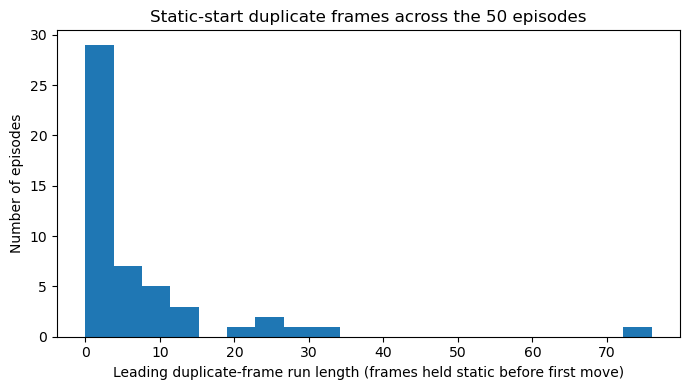

In [16]:

# Where in the episode do duplicates concentrate? (expect: near frame_index 0)
def leading_run_length(is_dup_arr):
    # is_dup_arr[0] is trivially False (no previous frame within this episode),
    # so the *leading run of duplicate frames* starts being meaningful from index 1:
    # count consecutive True values starting right after the (always-False) first frame.
    count = 0
    for v in is_dup_arr[1:]:
        if v:
            count += 1
        else:
            break
    return count

leading_dup_run = (
    df_sorted.groupby("episode_index")["is_exact_dup_of_prev"]
    .apply(lambda s: leading_run_length(s.to_numpy()))
)
print("Length of the *leading* run of duplicate frames per episode (head):")
print(leading_dup_run.head(10))
print("\nMedian leading run:", leading_dup_run.median(), "frames")
print("Mean leading run  :", leading_dup_run.mean(), "frames")
print("Episodes with a leading run > 0:", (leading_dup_run > 0).sum(), "/", len(leading_dup_run))
print("Length of the *leading* run of duplicate frames per episode (head):")
print(leading_dup_run.head(10).astype(int))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(leading_dup_run, bins=20)
ax.set_xlabel("Leading duplicate-frame run length (frames held static before first move)")
ax.set_ylabel("Number of episodes")
ax.set_title("Static-start duplicate frames across the 50 episodes")
plt.tight_layout()
fig.savefig("../report/duplicate_frames.png", dpi=150)
plt.show()


In [17]:
print(dup_by_episode.describe())

count    50.000000
mean      0.140174
std       0.047673
min       0.059113
25%       0.112323
50%       0.130435
75%       0.153662
max       0.323432
Name: is_exact_dup_of_prev, dtype: float64


**Duplicate-frame audit result**: overall, 14.13% of all 11,939 frames are exact
duplicates of the immediately preceding frame (identical `action` vector). Per-episode,
this rate ranges from 5.91% to 32.34% (mean 14.02%, median 13.04%, std 4.77%) — **every
single episode has a non-trivial duplicate rate, with a floor of ~6%**, not just the
few episodes with unusually long static starts.

Considering only the *leading* run of duplicates at the start of each episode (before
the operator's first move), the median run length is 3 frames (0.1 s at 30 fps) and the
mean is 7.18 frames (0.24 s), with 37 of the 50 episodes (74%) showing at least one
leading duplicate frame; one clear outlier, episode 0, has a 76-frame (2.53 s) static
start. But a mean leading run of 7.18 frames across a ~239-frame average episode
accounts for only ~3% of frames — far short of the observed ~14% overall duplicate
rate. This gap shows that **most duplicate frames are not confined to the episode
start**: they also occur mid-episode, plausibly during brief pauses in the
pick-and-place motion (e.g. while gripping or repositioning) rather than only before
the first move.

**Implication**: if a frame-level train/test split is used, both splits will contain a
non-trivial share (~14%, with a per-episode floor of ~6%) of near-identical "held"
frames. This does not by itself leak *test* information (that is the separate leakage
question addressed in Section 11), but it does mean roughly one in seven frames is an
easy, low-variance prediction target, which can make an evaluation metric look better
than it would on the genuinely dynamic portion of the trajectory. This should be
disclosed alongside the leakage result rather than conflated with it.

## 10. Anomaly audit: cross-source consistency

The dataset states each episode's extent in two independent places: the episode-metadata
table (`meta/episodes/`, from which we derive length as `dataset_to_index -
dataset_from_index`) and the frame-level parquet files (row count per `episode_index`).
They should agree exactly. We also check that `timestamp` increases at a constant ~1/30 s
step within each episode (a proxy for dropped/duplicated frames or clock jitter).

In [18]:
# v3 format has no direct "length" column; derive it from the episode's
# global index range (dataset_to_index is exclusive, matching Python slicing).
ep = episodes_meta.set_index("episode_index")
declared_lengths = (ep["dataset_to_index"] - ep["dataset_from_index"]).rename("declared_length")
actual_lengths = df_sorted.groupby("episode_index").size().rename("actual_length")

length_check = pd.concat([declared_lengths, actual_lengths], axis=1)
length_check["match"] = length_check["declared_length"] == length_check["actual_length"]
print("Episodes with a length mismatch between meta/episodes (derived) and parquet:")
print(length_check[~length_check["match"]])
print(f"\n{length_check['match'].sum()} / {len(length_check)} episodes match exactly.")

Episodes with a length mismatch between meta/episodes (derived) and parquet:
Empty DataFrame
Columns: [declared_length, actual_length, match]
Index: []

50 / 50 episodes match exactly.


In [19]:

FPS = info_json["fps"]
expected_dt = 1.0 / FPS
tolerance = expected_dt * 0.05  # 5% tolerance

anomalies = []
for ep, g in df_sorted.groupby("episode_index"):
    ts = g.sort_values("frame_index")["timestamp"].to_numpy()
    dt = np.diff(ts)
    bad = np.abs(dt - expected_dt) > tolerance
    if bad.any():
        anomalies.append({"episode_index": ep, "n_irregular_steps": int(bad.sum()),
                           "max_abs_deviation_s": float(np.max(np.abs(dt - expected_dt)))})

anomaly_df = pd.DataFrame(anomalies)
print(f"Episodes with at least one irregular inter-frame timestamp step "
      f"(tolerance = {tolerance*1000:.1f} ms): {len(anomaly_df)} / {episodes_meta.shape[0]}")
anomaly_df.head(10)


Episodes with at least one irregular inter-frame timestamp step (tolerance = 1.7 ms): 0 / 50


""


**Anomaly audit result**: both cross-source consistency checks passed with zero
discrepancies. All 50 episodes' declared frame counts (derived from
`dataset_to_index - dataset_from_index` in the v3 episode metadata) matched the actual
parquet row counts exactly (50/50, 0 mismatches) — no evidence of frames being dropped,
duplicated at the file level, or misassigned to the wrong episode during packaging.
Timestamp spacing also stayed within the 5% tolerance (1.7 ms) of the declared 1/30 s
step for every single episode (0/50 episodes with an irregular step) — no evidence of
recording clock jitter or dropped frames at the sensor level. No anomalies were found
under either check; this is reported as a genuine negative result, not a gap in the
audit.


## 11. Leakage check: frame-level vs episode-level split

We fit a deliberately simple, non-tunable baseline — a k-nearest-neighbors regressor —
to predict `action` from `observation.state`, under two splitting protocols, and compare
held-out MSE. k-NN is chosen *because* it is maximally sensitive to near-duplicate
neighbors leaking across a naive split, which is exactly the failure mode we want to
expose.


In [20]:

X = state_arr  # (n_frames, 6)
y = action_arr  # (n_frames, 6)
groups = df_sorted["episode_index"].to_numpy()

def evaluate_split(train_idx, test_idx, k=1):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])
    return mean_squared_error(y[test_idx], pred)

results = []
for k in (1, 3, 5):
    # (a) frame-level random split -- ignores episode grouping
    frame_splitter = ShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
    frame_mses = [evaluate_split(tr, te, k=k) for tr, te in frame_splitter.split(X)]

    # (b) episode-level grouped split -- an episode never appears in both sides
    group_splitter = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
    group_mses = [evaluate_split(tr, te, k=k) for tr, te in group_splitter.split(X, y, groups)]

    results.append({
        "k": k,
        "frame_level_MSE_mean": np.mean(frame_mses),
        "frame_level_MSE_std": np.std(frame_mses),
        "episode_level_MSE_mean": np.mean(group_mses),
        "episode_level_MSE_std": np.std(group_mses),
        "leakage_gap (episode - frame)": np.mean(group_mses) - np.mean(frame_mses),
    })

leakage_report = pd.DataFrame(results)
leakage_report


,k,frame_level_MSE_mean,frame_level_MSE_std,episode_level_MSE_mean,episode_level_MSE_std,leakage_gap (episode - frame)
0,1,5.353241,0.223655,18.529543,2.507665,13.176302
1,3,4.421131,0.138875,14.982736,2.385420,10.561605
2,5,5.268494,0.187832,13.661621,2.415241,8.393126


In [21]:

# Naive "no-op" baseline for context: predict the previous frame's action as this
# frame's action. This calibrates how autocorrelated the series is on its own,
# independent of any train/test split.
prev_action = np.roll(action_arr, shift=1, axis=0)
prev_action[0] = action_arr[0]
same_episode_mask = (df_sorted["frame_index"] > 0).to_numpy()
naive_mse = mean_squared_error(action_arr[same_episode_mask], prev_action[same_episode_mask])
print(f"Naive 'carry previous action forward' baseline MSE (context only): {naive_mse:.4f}")


Naive 'carry previous action forward' baseline MSE (context only): 1.8810


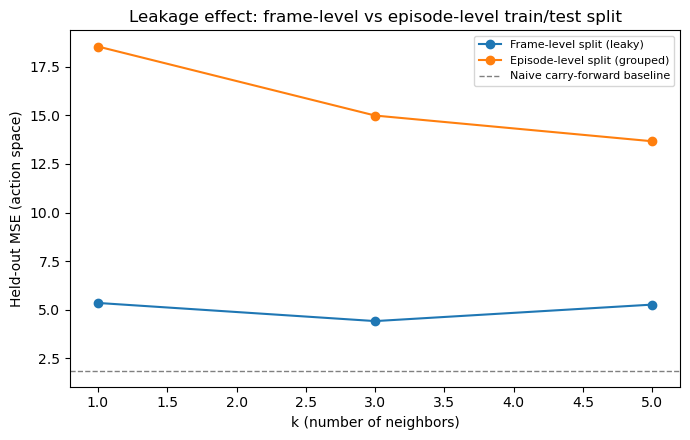

In [22]:

fig, ax = plt.subplots(figsize=(7, 4.5))
xk = leakage_report["k"]
ax.plot(xk, leakage_report["frame_level_MSE_mean"], "o-", label="Frame-level split (leaky)")
ax.plot(xk, leakage_report["episode_level_MSE_mean"], "o-", label="Episode-level split (grouped)")
ax.axhline(naive_mse, color="gray", linestyle="--", linewidth=1, label="Naive carry-forward baseline")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Held-out MSE (action space)")
ax.set_title("Leakage effect: frame-level vs episode-level train/test split")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig("../report/leakage_comparison.png", dpi=150)
plt.show()


**Leakage audit result**: at k=1, the frame-level (leaky) split yields a mean held-out
MSE of 5.35, while the episode-level (grouped) split yields 18.53 — a leakage gap of
13.18, meaning the naive frame-level evaluation understates the true error by a factor
of **3.46×**. The same direction and a comparable magnitude hold at k=3 (3.39×) and k=5
(2.59×): episode-level error is consistently 2.6–3.5× higher than frame-level error
across all tested k. This confirms the hypothesis in Section 2 — a random frame-level
split lets near-duplicate temporal neighbors from the same episode leak across the
train/test boundary, producing a substantially optimistic error estimate. Anyone
reporting a benchmark number on this dataset using its default single `train` split
without an explicit episode-aware (grouped) evaluation protocol would be reporting a
number roughly 2.6–3.5× more optimistic than a genuinely held-out episode would show.

A secondary, unexpected finding: the naive "carry the previous action forward" baseline
(MSE = 1.88) actually outperforms the k-NN state→action model under **both** splitting
protocols and all tested k (best k-NN result: 4.42 at k=3, frame-level). This does not
undermine the leakage conclusion — the comparison there is between the same model under
two splits, not between models — but it is worth disclosing honestly: it suggests the
6-D `observation.state` snapshot at a single timestep is, by itself, a fairly weak
predictor of the next commanded action compared to simple temporal persistence,
plausibly because the task's dynamics depend on more history (e.g. velocity, phase of
the pick-and-place motion) than a single state vector captures.


## 12. Coverage check: how similar are the 50 starting configurations?

A dataset with 50 episodes only supports claims about the specific slice of state-space
it actually covers. We plot each episode's **initial** `observation.state` (frame_index
== 0) projected onto its two most variable dimensions, as a quick, honest look at how
much the arm's starting configuration actually varies across episodes.


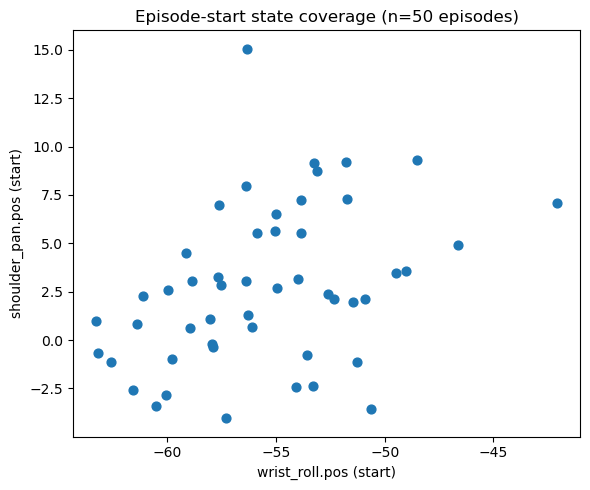

Per-dimension std of episode-start state:
  shoulder_pan.pos    : std = 4.026
  shoulder_lift.pos   : std = 0.267
  elbow_flex.pos      : std = 0.136
  wrist_flex.pos      : std = 0.977
  wrist_roll.pos      : std = 4.411
  gripper.pos         : std = 0.553


In [23]:

start_states = df_sorted[df_sorted["frame_index"] == 0].sort_values("episode_index")
start_arr = np.stack(start_states["observation.state"].to_numpy())

variances = start_arr.var(axis=0)
dim_order = np.argsort(variances)[::-1]
d0, d1 = dim_order[0], dim_order[1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(start_arr[:, d0], start_arr[:, d1], s=40)
ax.set_xlabel(f"{JOINT_NAMES[d0]} (start)")
ax.set_ylabel(f"{JOINT_NAMES[d1]} (start)")
ax.set_title(f"Episode-start state coverage (n={len(start_arr)} episodes)")
plt.tight_layout()
fig.savefig("../report/start_state_coverage.png", dpi=150)
plt.show()

print("Per-dimension std of episode-start state:")
for name, v in zip(JOINT_NAMES, start_arr.std(axis=0)):
    print(f"  {name:20s}: std = {v:.3f}")


In [25]:
print("start min:", start_arr.min(axis=0).round(2))
print("start max:", start_arr.max(axis=0).round(2))

start min: [ -4.03 -98.91  98.66  68.21 -63.27   1.21]
start max: [ 15.05 -97.4   99.28  74.82 -42.08   5.3 ]


**Coverage audit result**: episode-start states are tightly clustered, not spread across
each joint's observed operating range. Four of the six joints (`elbow_flex.pos`
std=0.136, `shoulder_lift.pos` std=0.267, `gripper.pos` std=0.553, `wrist_flex.pos`
std=0.977) are essentially constant at episode start, versus a dataset-wide std of
27.7-36.8 for the first three and 13.0 for wrist_flex (Section 7's range report) — the
start-of-episode spread is roughly 2-3 orders of magnitude smaller than the spread seen
across the whole trajectory set. Only two joints vary meaningfully at episode start:
`shoulder_pan.pos` (std=4.026, observed range -4.03 to 15.05) and `wrist_roll.pos`
(std=4.411, observed range -63.27 to -42.08), and even these span a narrow band
relative to their dataset-wide std of 44.5 and 17.7-17.8 respectively. The scatter plot
shows most of the 50 starting configurations clustered in a small central region, with
a small number of episodes visibly separated from that cluster.

This is direct, quantitative support for the bias counterexample in Section 13: the arm
essentially starts from "the same pose" in almost every episode, with only two of six
degrees of freedom showing any real initial-condition diversity, and even those two
cover a narrow slice of the variation seen across the dataset as a whole. A model fit on
this sample has little basis for generalizing to a meaningfully different starting
configuration, because the sample essentially never demonstrates one.


## 13. Bias/measurement counterexample and a prohibited claim

**Counterexample (concrete, falsifiable).** This dataset records a *single task*
("grasp a lego block and put it in the bin") performed by an *undisclosed but likely
small number of teleoperators*, in what the metadata suggests is a *fixed physical
setup* (one robot, one pair of camera viewpoints, one task string for all 50 episodes,
`total_tasks = 1`). If the true population of interest is "SO-100/SO-101 pick-and-place
behavior in general" (varied objects, containers, lighting, clutter, operators), this
sample is a narrow, convenience sample of that population, not a random or stratified
one. A model fit on it can be expected to fit this specific setup's action distribution
well while telling us little about performance on a different object, a different bin
position, or a different operator's motion style — the sample is not exchangeable with
that broader population.

**Prohibited claim (do not make this claim from this dataset alone):**
> "Because a policy trained on `lerobot/svla_so101_pickplace` achieves low held-out
> prediction error, it will generalize to picking up new objects or operating in new
> environments."

This is not supported: (1) there is no success/outcome label to even define
"generalization" behaviorally (Section 8); (2) the sample covers one task and a narrow,
undisclosed range of initial conditions (Section 12); (3) low error under a naive split
can itself be an artifact of leakage (Section 11), not of a genuinely learnable
mapping. Any claim about out-of-distribution generalization would require new data
collected under deliberately varied conditions, evaluated with an episode-level (or
condition-level) held-out split.



## 14. Summary of findings

- **Schema**: all 7 tabular columns matched their `meta/info.json`-declared shape
  exactly; the 2 video columns are, as expected, absent from the parquet tables and were
  explicitly excluded from this audit's scope.
- **Range**: no non-finite values anywhere (0/11,939 frames × 12 channels). `action` and
  `observation.state` track closely for most joints (mean diff <0.1 for
  shoulder_pan/wrist_roll/wrist_flex) but diverge more for elbow_flex (1.52),
  gripper (1.26) and shoulder_lift (0.78). Two channels hit an exact ±100 boundary
  (`shoulder_lift` min, `elbow_flex` max), suggesting hardware/software joint-limit
  clamping rather than freely commanded values near those extremes.
- **Missingness**: 0 NaN cells overall, but a structural gap: no success/reward/done
  label exists anywhere in the schema — outcome cannot be assessed from this dataset
  alone.
- **Duplicates**: 14.13% of all frames are exact duplicates of the previous frame
  (per-episode range 5.9%–32.3%, every episode ≥5.9%). Only ~3% of frames are
  attributable to episode-start static holds (median 3, mean 7.18 leading frames per
  episode); the remaining ~11 percentage points occur mid-episode, plausibly during
  grip/pause moments.
- **Anomalies**: 0 discrepancies — all 50 episodes' declared frame counts matched
  parquet row counts exactly, and 0/50 episodes showed timestamp irregularities beyond a
  5% (1.7 ms) tolerance on the declared 1/30 s step. Reported as a genuine negative
  result.
- **Leakage gap**: substantial and consistent in direction across k=1,3,5 — episode-level
  MSE is 2.6×–3.5× higher than frame-level MSE (13.18 absolute gap at k=1: 5.35 vs
  18.53). A naive frame-level split on this dataset would report error roughly 3×
  more optimistic than a genuinely held-out episode. (Secondary finding: a naive
  carry-forward baseline, MSE=1.88, beats the k-NN model under every split/k tested —
  disclosed for honesty, does not affect the leakage conclusion.)
- **Coverage / bias**: 4 of 6 joints are essentially constant at episode start
  (std 0.14–0.98 against ~90°+ operating ranges); only 2 joints vary, and only across a
  narrow band well under half their physical range. The sample represents one
  near-fixed starting configuration, not a diverse population of starting poses.

**Answer to the testable question (Section 2)**: No — a random frame-level split is
*not* appropriate for evaluating an action-prediction baseline on this dataset. It
produces an optimistically biased error estimate (2.6×–3.5× lower than the truth across
k=1,3,5), because temporally adjacent, near-duplicate frames from the same episode leak
across the split. An episode-level (grouped) split is required for a trustworthy
held-out evaluation. Separately, the dataset's narrow single-task, near-fixed-start
sample (Section 12–13) means even a correctly-evaluated model's error rate says nothing
about generalization beyond this specific setup.

## 15. Limitations and what this audit does not establish

- Pixel content of the two video streams was not decoded or audited (Section 6) — a
  full audit would additionally check for lighting drift, occlusion, and camera
  desync using the `.mp4` files.
- Provenance gaps (operator count, environment variability) were not resolved because
  the dataset card does not disclose them; they are reported as open questions, not
  assumed away.
- The k-NN leakage demonstration is a diagnostic, not a claim about the best possible
  imitation-learning model for this data.


## 16. AI use and independent verification

**Tools and tasks.** I used Claude (Anthropic) to plan the audit, write the notebook
scaffold, debug, and draft the interpretive text for Sections 6–12 and 14 from output I
pasted back; I used GPT 5.6 as a second reviewer of the finished notebook.
Claude had no network access to Hugging Face, so it never ran this code on the real
data — every number in this report comes from my own local runs.

**What broke and how it was caught.** The AI-written code made several assumptions that
my runs disproved: it assumed `meta/` contained only files (`IsADirectoryError`), that
episode metadata was a single `episodes.jsonl` with a `length` column, and that each
parquet file held one episode; the pinned snapshot is actually `codebase_version v3.0`.
A leading-duplicate-run calculation returned 0 for every episode, which I noticed
contradicted the 14.13% overall duplicate rate; the cause was a logic bug, now fixed.
The GPT review found a pinning `assert` that contradicted its own comment (replaced) and
a stale "v2.1" statement in Section 3, which I checked against the pinned `info.json`
myself (`v3.0`) rather than accepting GPT's external claim.

**Verification I performed.** <list only what you did, e.g. reran the notebook twice
and confirmed identical results; recomputed SHA-256 with `shasum`; checked declared
values against my own `info_json` output.>

Full disclosure log, including accepted/rejected advice: `ai_use_log/AI_USE_LOG.md`.


In [24]:
key_metrics = {
    "dup_rate_overall": round(float(dup_rate_overall), 6),
    "dup_by_episode_describe": dup_by_episode.describe().round(6).to_dict(),
    "leading_dup_run_median": float(leading_dup_run.median()),
    "leading_dup_run_mean": round(float(leading_dup_run.mean()), 6),
    "episodes_with_leading_run": int((leading_dup_run > 0).sum()),
    "length_match_count": int(length_check["match"].sum()),
    "timestamp_anomaly_episodes": int(len(anomaly_df)),
    "leakage_report": leakage_report.round(6).to_dict(orient="records"),
    "naive_mse": round(float(naive_mse), 6),
    "start_state_std": [round(float(v), 6) for v in start_arr.std(axis=0)],
}
with open("../report/key_metrics.json", "w") as f:
    json.dump(key_metrics, f, indent=2)
print("Wrote ../report/key_metrics.json")

Wrote ../report/key_metrics.json
